In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.optimize import curve_fit
from tqdm.auto import tqdm

project_root = os.path.abspath(
    os.path.join(os.getcwd(), "../../..")
)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import model as md
importlib.reload(md)

import json
import re

from pathlib import Path
from datetime import datetime

In [28]:
METHODS =[
    md.get_phase_MP,
    md.get_phase_ZCRR,
    md.get_phase_FFT,
    md.get_phase_HB,
    md.get_phase_XCOR,
    md.get_phase_LI,
    md.get_phase_SWFR
]

def method_label(method_or_name):
    name = (
        method_or_name
        if isinstance(method_or_name, str)
        else method_or_name.__name__
    )

    return name.removeprefix("get_phase_")

SIMULATION = {
    "F": 400e3,
    "gen_unstable": 0.1,
    "phase_real": 70,
    "bits": 12,
    "SNR": 60,
    "adc_range": 1,
    "iterations": 50,
}

In [18]:
def run_phase_sweep(
    x_values,
    make_time,
    methods=METHODS,
    simulation=SIMULATION,
    simulation_parameter=None,
    value_cast=None,
    description="Моделирование"
):
    """
    Выполняет моделирование для значений x_values.

    simulation_parameter:
        Имя параметра из SIMULATION, который нужно варьировать.
        Например: "bits", "SNR", "phase_real".

    value_cast:
        Преобразование варьируемого значения.
        Например int для количества бит.
    """

    x_values = np.asarray(x_values, dtype=float)

    results = {
        method.__name__: np.full(len(x_values), np.nan)
        for method in methods
    }

    failure_count = {
        method.__name__: 0
        for method in methods
    }

    for x_index, x_value in enumerate(
        tqdm(x_values, desc=description)
    ):
        # Отдельная копия параметров для текущего значения X
        current_simulation = simulation.copy()

        if simulation_parameter is not None:

            parameter_value = (
                value_cast(x_value)
                if value_cast is not None
                else x_value
            )

            current_simulation[
                simulation_parameter
            ] = parameter_value

        t = np.asarray(
            make_time(x_value, current_simulation),
            dtype=float
        )

        if t.ndim != 1 or len(t) < 2:
            raise ValueError(
                f"Для x={x_value} получен некорректный "
                f"массив времени длиной {len(t)}."
            )

        current_errors = {
            method.__name__: []
            for method in methods
        }

        for _ in range(current_simulation["iterations"]):

            phase = md.generate_common_phase(
                t,
                current_simulation["F"],
                current_simulation["gen_unstable"],
                phase0_deg=0
            )

            U, I = md.generate_signals_from_phase(
                phase,
                phase_diff_deg=current_simulation["phase_real"]
            )

            U = md.add_SNR(
                U,
                current_simulation["SNR"]
            )

            I = md.add_SNR(
                I,
                current_simulation["SNR"]
            )

            U = md.adc_quantize(
                U,
                int(current_simulation["bits"]),
                current_simulation["adc_range"]
            )

            I = md.adc_quantize(
                I,
                int(current_simulation["bits"]),
                current_simulation["adc_range"]
            )

            for method in methods:

                method_name = method.__name__

                try:
                    phase_estimated = float(
                        method(
                            t,
                            U,
                            I,
                            current_simulation["F"]
                        )
                    )

                    error = abs(
                        abs(current_simulation["phase_real"])
                        - abs(phase_estimated)
                    )

                    if np.isfinite(error):
                        current_errors[
                            method_name
                        ].append(error)

                except Exception:
                    failure_count[method_name] += 1

        for method_name, errors in current_errors.items():

            if errors:
                results[method_name][x_index] = np.mean(
                    errors
                )

    failed_methods = {
        method_label(name): count
        for name, count in failure_count.items()
        if count > 0
    }

    if failed_methods:
        print("Количество ошибок методов:")
        print(failed_methods)

    return results

In [4]:
def exp_decay(x, A, B, C):
    return A * np.exp(-B * x) + C


def calculate_saturation_point(
    x_data,
    y_data,
    fraction=0.03
):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(x_data)
        & np.isfinite(y_data)
        & (y_data >= 0)
    )

    x_valid = x_data[valid]
    y_valid = y_data[valid]

    if len(x_valid) < 4:
        return None

    y_valid = np.maximum(y_valid, 1e-15)

    initial_parameters = [
        max(np.max(y_valid) - np.min(y_valid), 1e-12),
        0.05,
        max(np.min(y_valid), 0)
    ]

    try:
        parameters, _ = curve_fit(
            exp_decay,
            x_valid,
            y_valid,
            p0=initial_parameters,
            bounds=(
                [0, 1e-10, 0],
                [np.inf, np.inf, np.inf]
            ),
            maxfev=20_000
        )

    except (RuntimeError, ValueError, FloatingPointError):
        return None

    A, B, C = parameters

    if B <= 0 or not np.isfinite(B):
        return None

    x_min = np.min(x_valid)
    x_saturation = x_min - np.log(fraction) / B

    y_approximation = exp_decay(
        x_valid,
        *parameters
    )

    ss_res = np.sum(
        (y_valid - y_approximation) ** 2
    )

    ss_tot = np.sum(
        (y_valid - np.mean(y_valid)) ** 2
    )

    r_squared = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    return {
        "parameters": parameters,
        "x_sat": x_saturation,
        "r_squared": r_squared
    }

In [5]:
def calculate_all_saturations(
    x_data,
    results,
    methods=METHODS,
    fraction=0.03
):
    x_data = np.asarray(x_data, dtype=float)

    saturation_results = {}

    for method in methods:

        method_name = method.__name__

        result = calculate_saturation_point(
            x_data,
            results[method_name],
            fraction=fraction
        )

        if result is not None:
            saturation_results[method_name] = result

    valid_results = {
        name: result
        for name, result in saturation_results.items()
        if (
            np.isfinite(result["x_sat"])
            and np.min(x_data) <= result["x_sat"] <= np.max(x_data)
        )
    }

    if valid_results:
        max_method = max(
            valid_results,
            key=lambda name: valid_results[name]["x_sat"]
        )

        max_x_sat = valid_results[max_method]["x_sat"]

    else:
        max_method = None
        max_x_sat = None

    return saturation_results, max_method, max_x_sat

In [6]:
def show_saturation_table(
    saturation_results,
    parameter_name,
    methods=METHODS
):
    rows = []

    for method in methods:

        method_name = method.__name__
        result = saturation_results.get(method_name)

        rows.append({
            "Метод": method_label(method_name),
            f"Точка насыщения, {parameter_name}": (
                result["x_sat"]
                if result is not None
                else np.nan
            ),
            "R² аппроксимации": (
                result["r_squared"]
                if result is not None
                else np.nan
            )
        })

    table = pd.DataFrame(rows)

    display(
        table.style.format({
            f"Точка насыщения, {parameter_name}": "{:.2f}",
            "R² аппроксимации": "{:.4f}"
        })
    )

    return table

In [34]:
def replace_spikes(
    x_data,
    y_data,
    x_start=0,
    y_threshold=None,
    lower_threshold=None
):
    """
    Убирает выбросы только для отображения графика.

    y_threshold:
        Значения выше этого порога считаются выбросами вверх.

    lower_threshold:
        Значения ниже этого порога считаются выбросами вниз.

    Выбросы заменяются интерполяцией между нормальными
    точками в логарифмическом масштабе.
    """

    x_data = np.asarray(x_data, dtype=float)
    y_filtered = np.asarray(y_data, dtype=float).copy()

    valid = (
        np.isfinite(x_data)
        & np.isfinite(y_filtered)
        & (y_filtered > 0)
    )

    checked_range = valid & (x_data > x_start)

    spikes = np.zeros(len(y_filtered), dtype=bool)

    # Выбросы вверх
    if y_threshold is not None:
        spikes |= (
            checked_range
            & (y_filtered > y_threshold)
        )

    # Выбросы вниз
    if lower_threshold is not None:
        spikes |= (
            checked_range
            & (y_filtered < lower_threshold)
        )

    normal_points = valid & ~spikes

    # Для интерполяции нужны хотя бы две нормальные точки
    if np.sum(normal_points) >= 2 and np.any(spikes):

        # Интерполируем log10(y), поскольку график логарифмический
        log_y_normal = np.log10(
            y_filtered[normal_points]
        )

        interpolated_log_y = np.interp(
            x_data[spikes],
            x_data[normal_points],
            log_y_normal
        )

        y_filtered[spikes] = 10 ** interpolated_log_y

    return y_filtered

In [15]:
def plot_phase_results(
    x_data,
    results,
    x_label,
    methods=METHODS,
    max_saturation_method=None,
    max_x_sat=None,
    spike_rules=None,
    figsize=(7, 5)
):
    """
    spike_rules имеет вид:

    {
        "get_phase_XCOR": {
            "x_start": 10,
            "y_threshold": 1e-1
        }
    }
    """

    x_data = np.asarray(x_data, dtype=float)
    spike_rules = spike_rules or {}

    fig, ax = plt.subplots(figsize=figsize)

    for method in methods:

        method_name = method.__name__

        y_data = np.asarray(
            results[method_name],
            dtype=float
        ).copy()

        # Фильтрация применяется только к изображению
        if method_name in spike_rules:
            y_data = replace_spikes(
                x_data,
                y_data,
                **spike_rules[method_name]
            )

        valid = (
            np.isfinite(x_data)
            & np.isfinite(y_data)
            & (y_data > 0)
        )

        ax.plot(
            x_data[valid],
            y_data[valid],
            linewidth=1.6,
            alpha=0.9,
            label=method_label(method_name)
        )

    #if (
    #    max_saturation_method is not None
    #    and max_x_sat is not None
    #):
    #    ax.axvline(
    #        max_x_sat,
    #        color="black",
    #        linestyle="--",
    #        linewidth=1.8,
    #        label=(
    #            "Пороговые значения: "
    #            f"{method_label(max_saturation_method)}, "
    #            f"{max_x_sat:.1f}"
    #        )
    #    )
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(
        ticker.LogLocator(
            base=10,
            numticks=12
        )
    )

    ax.yaxis.set_major_formatter(
        ticker.LogFormatterMathtext(base=10)
    )

    ax.yaxis.set_minor_locator(
        ticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
            numticks=100
        )
    )

    ax.yaxis.set_minor_formatter(
        ticker.NullFormatter()
    )

    ax.grid(
        True,
        which="major",
        linestyle=":",
        linewidth=0.8,
        alpha=0.7
    )

    ax.grid(
        True,
        which="minor",
        axis="y",
        linestyle=":",
        linewidth=0.5,
        alpha=0.35
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Error, °")
    ax.set_xlim(np.min(x_data), np.max(x_data))

    legend_items = len(methods)

    if max_saturation_method is not None:
        legend_items += 1

    legend_columns = min(4, legend_items)
    legend_rows = int(np.ceil(legend_items / legend_columns))

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=legend_columns,
        frameon=True,
        fontsize=9
    )

    bottom_space = 0.12 + 0.055 * legend_rows

    fig.tight_layout(
        rect=[0, bottom_space, 1, 1]
    )

    plt.show()

In [9]:
def make_safe_filename(name):
    """
    Удаляет из имени файла символы, недопустимые в Windows.
    """

    name = str(name).strip()

    # Пробелы и недопустимые символы заменяем подчёркиванием
    name = re.sub(r'[<>:"/\\|?*\s]+', "_", name)

    # Удаляем лишние подчёркивания
    name = re.sub(r"_+", "_", name)

    return name.strip("._")


def json_converter(value):
    """
    Преобразует типы NumPy для сохранения в JSON.
    """

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    return str(value)


def save_sweep_data(
    variable_name,
    x_data,
    results,
    x_label=None,
    parameter_name=None,
    simulation=None,
    folder="saved_sweeps",
    add_timestamp=True
):
    """
    Сохраняет результаты варьирования в один NPZ-файл.

    Parameters
    ----------
    variable_name:
        Имя варьируемой переменной для имени файла,
        например 'fs_mult' или 'duration_T'.

    x_data:
        Значения варьируемой переменной.

    results:
        Словарь вида:
        {
            "get_phase_MP": [...],
            "get_phase_FFT": [...],
            ...
        }

    x_label:
        Подпись оси X на графике.

    parameter_name:
        Название параметра в таблице насыщения.

    simulation:
        Словарь параметров моделирования.
    """

    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)

    safe_name = make_safe_filename(variable_name)

    if not safe_name:
        raise ValueError(
            "Не удалось получить корректное имя файла."
        )

    created_at = datetime.now()

    if add_timestamp:
        timestamp = created_at.strftime("%Y%m%d_%H%M%S")
        filename = f"{safe_name}_{timestamp}.npz"
    else:
        filename = f"{safe_name}.npz"

    file_path = folder / filename

    metadata = {
        "variable_name": variable_name,
        "x_label": x_label,
        "parameter_name": (
            parameter_name
            if parameter_name is not None
            else variable_name
        ),
        "created_at": created_at.isoformat(
            timespec="seconds"
        ),
        "simulation": simulation or {},
        "method_names": list(results.keys())
    }

    arrays_to_save = {
        "x_data": np.asarray(x_data, dtype=float),

        "metadata_json": np.asarray(
            json.dumps(
                metadata,
                ensure_ascii=False,
                default=json_converter
            )
        )
    }

    # Каждый метод сохраняется отдельным массивом
    for method_name, values in results.items():

        arrays_to_save[
            f"result__{method_name}"
        ] = np.asarray(values, dtype=float)

    np.savez_compressed(
        file_path,
        **arrays_to_save
    )

    print(f"Результаты сохранены:\n{file_path.resolve()}")

    return file_path

In [10]:
def load_sweep_data(
    variable_name_or_path,
    folder="saved_sweeps"
):
    """
    Загружает результаты варьирования.

    Можно передать:

    1. Полный путь к файлу:
       load_sweep_data("saved_sweeps/fs_mult_20260712_120000.npz")

    2. Только название переменной:
       load_sweep_data("fs_mult")

       В этом случае будет загружен самый новый файл,
       начинающийся с fs_mult.
    """

    folder = Path(folder)
    input_path = Path(variable_name_or_path)

    # Передан конкретный существующий файл
    if input_path.exists():
        file_path = input_path

    else:
        safe_name = make_safe_filename(
            variable_name_or_path
        )

        # Ищем обычный файл и файлы с временной меткой
        candidates = list(
            folder.glob(f"{safe_name}.npz")
        )

        candidates += list(
            folder.glob(f"{safe_name}_*.npz")
        )

        if not candidates:
            raise FileNotFoundError(
                f"Не найдены сохранённые данные "
                f"для переменной '{variable_name_or_path}' "
                f"в папке '{folder.resolve()}'."
            )

        # Выбираем самый новый файл
        file_path = max(
            candidates,
            key=lambda path: path.stat().st_mtime
        )

    with np.load(
        file_path,
        allow_pickle=False
    ) as saved_data:

        x_data = np.asarray(
            saved_data["x_data"],
            dtype=float
        )

        metadata = json.loads(
            saved_data["metadata_json"].item()
        )

        results = {}

        prefix = "result__"

        for key in saved_data.files:

            if key.startswith(prefix):

                method_name = key.removeprefix(prefix)

                results[method_name] = np.asarray(
                    saved_data[key],
                    dtype=float
                )

    # Проверка размеров массивов
    invalid_lengths = {
        method_name: len(values)
        for method_name, values in results.items()
        if len(values) != len(x_data)
    }

    if invalid_lengths:
        raise ValueError(
            "Размеры результатов некоторых методов "
            f"не совпадают с x_data: {invalid_lengths}"
        )

    print(f"Загружены результаты:\n{file_path.resolve()}")
    print(
        f"Дата сохранения: "
        f"{metadata.get('created_at', 'не указана')}"
    )

    return x_data, results, metadata

In [11]:
def get_methods_from_results(
    results,
    module=md
):
    """
    Восстанавливает список функций методов по их именам.
    """

    methods = []
    missing_methods = []

    for method_name in results:

        method = getattr(
            module,
            method_name,
            None
        )

        if callable(method):
            methods.append(method)
        else:
            missing_methods.append(method_name)

    if missing_methods:
        raise AttributeError(
            "В модуле model не найдены методы: "
            + ", ".join(missing_methods)
        )

    return methods

In [19]:
def load_analyze_and_plot(
    variable_name,
    spike_rules=None
):
    """
    Загружает последнее сохранённое варьирование,
    рассчитывает насыщение, выводит таблицу и график.
    """

    x_data, estimated_diff, metadata = load_sweep_data(
        variable_name
    )

    loaded_methods = get_methods_from_results(
        estimated_diff
    )

    saturation_results, max_method, max_x_sat = (
        calculate_all_saturations(
            x_data=x_data,
            results=estimated_diff,
            methods=loaded_methods
        )
    )

    show_saturation_table(
        saturation_results=saturation_results,
        parameter_name=metadata.get(
            "parameter_name",
            metadata["variable_name"]
        ),
        methods=loaded_methods
    )

    plot_phase_results(
        x_data=x_data,
        results=estimated_diff,
        x_label=metadata.get(
            "x_label",
            metadata["variable_name"]
        ),
        methods=loaded_methods,
        max_saturation_method=max_method,
        max_x_sat=max_x_sat,
        spike_rules=spike_rules
    )

    return {
        "x_data": x_data,
        "results": estimated_diff,
        "metadata": metadata,
        "saturation_results": saturation_results,
        "max_method": max_method,
        "max_x_sat": max_x_sat
    }

In [12]:
DURATION_T = 60

fs_mult_range = np.arange(3, 150)


def time_for_fs_mult(fs_mult, simulation):
    fs = simulation["F"] * fs_mult

    number_of_samples = int(
        round(DURATION_T * fs_mult)
    )

    return np.arange(number_of_samples) / fs

# Моделирование
estimated_diff = run_phase_sweep(
    fs_mult_range,
    time_for_fs_mult
)

# Сохранение
save_sweep_data(
    variable_name="fs_mult",
    x_data=fs_mult_range,
    results=estimated_diff,
    x_label=r"$Fs_m$",
    parameter_name=r"$Fs_m$",
    simulation=SIMULATION
)


Моделирование:   0%|          | 0/147 [00:00<?, ?it/s]

KeyboardInterrupt: 

Загружены результаты:
C:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\saved_sweeps\fs_mult_20260712_011601.npz
Дата сохранения: 2026-07-12T01:16:01


,Метод,"Точка насыщения, $Fs_m$",R² аппроксимации
0,MP,3.96,0.2362
1,ZCRR,9.18,0.9207
2,FFT,57.88,0.9250
3,HB,81.75,0.8120
4,XCOR,4.47,0.1267
5,LI,45.76,0.8860
6,SWFR,52.09,0.9244


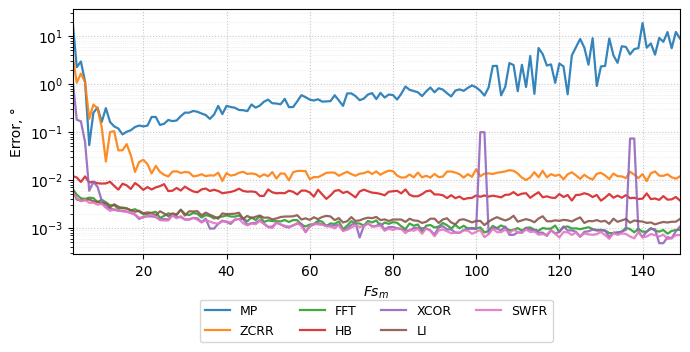

In [17]:
# Загрузка без повторного моделирования
x_data, estimated_diff, metadata = load_sweep_data(
    "fs_mult"
)

loaded_methods = get_methods_from_results(
    estimated_diff
)

saturation_results, max_method, max_x_sat = (
    calculate_all_saturations(
        x_data,
        estimated_diff,
        methods=loaded_methods
    )
)

show_saturation_table(
    saturation_results=saturation_results,
    parameter_name=metadata.get(
        "parameter_name",
        metadata["variable_name"]
    ),
    methods=loaded_methods
)

plot_phase_results(
    x_data=x_data,
    results=estimated_diff,
    x_label=metadata["x_label"],
    methods=loaded_methods,
    max_saturation_method=max_method,
    max_x_sat=max_x_sat,

    # Фильтрация выбросов только при рисовании
    spike_rules={
        "get_phase_XCOR": {
            "x_start": 10,
            "y_threshold": 1e-1
        }
    }
)

In [29]:
# ---------------------------------------------------------------------
# Варьирование длины сигнала
# ---------------------------------------------------------------------

FIXED_FS_MULT = 60

# Значения 3, 4, ..., 100
duration_T_range = np.arange(3, 101)


def time_for_duration(duration_T, simulation):
    """
    Создаёт временной массив для заданного
    количества периодов duration_T.
    """

    fs = simulation["F"] * FIXED_FS_MULT

    number_of_samples = int(
        round(duration_T * FIXED_FS_MULT)
    )

    return np.arange(number_of_samples) / fs


# Моделирование
duration_results = run_phase_sweep(
    x_values=duration_T_range,
    make_time=time_for_duration,
    description="Варьирование длины сигнала"
)


# Сохранение
save_sweep_data(
    variable_name="duration_T",
    x_data=duration_T_range,
    results=duration_results,
    x_label=r"Длина сигнала, $N_T$",
    parameter_name=r"$N_T$",
    simulation={
        **SIMULATION,
        "fixed_fs_mult": FIXED_FS_MULT,
        "duration_T_range": [3, 100]
    }
)

Варьирование длины сигнала:   0%|          | 0/98 [00:00<?, ?it/s]

KeyboardInterrupt: 

Загружены результаты:
C:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\saved_sweeps\duration_T_20260712_115731.npz
Дата сохранения: 2026-07-12T11:57:31


,Метод,"Точка насыщения, $N_T$",R² аппроксимации
0,MP,3.38,0.0161
1,ZCRR,70.13,0.8397
2,FFT,24.63,0.8036
3,HB,53.00,0.8055
4,XCOR,33.68,0.7929
5,LI,5.87,0.8860
6,SWFR,51.42,0.9082


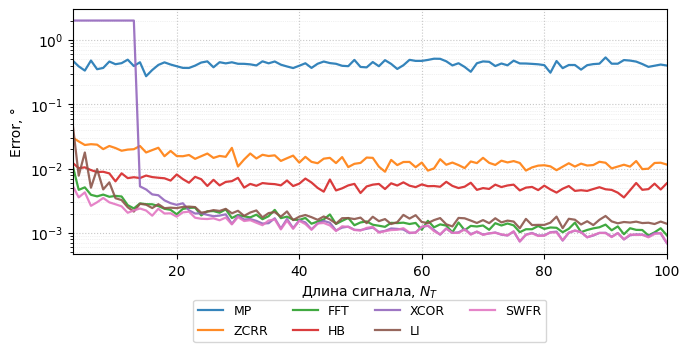

In [21]:
duration_loaded = load_analyze_and_plot(
    variable_name="duration_T",
    spike_rules={
        "get_phase_XCOR": {
            "x_start": 10,
            "y_threshold": 1e-1
        }
    }
)

In [30]:
# ---------------------------------------------------------------------
# Варьирование разрядности АЦП
# ---------------------------------------------------------------------

FIXED_DURATION_T = 60
FIXED_FS_MULT = 60

# Значения 3, 4, ..., 35
bits_range = np.arange(3, 36)


def time_for_bits(bits, simulation):
    """
    При варьировании bits временной массив остаётся
    одинаковым. Аргумент bits здесь не используется.
    """

    fs = simulation["F"] * FIXED_FS_MULT

    number_of_samples = int(
        round(FIXED_DURATION_T * FIXED_FS_MULT)
    )

    return np.arange(number_of_samples) / fs


# Моделирование
bits_results = run_phase_sweep(
    x_values=bits_range,
    make_time=time_for_bits,

    # Текущее значение X записывается в SIMULATION["bits"]
    simulation_parameter="bits",
    value_cast=lambda value: int(round(value)),

    description="Варьирование разрядности АЦП"
)


# Сохранение
save_sweep_data(
    variable_name="bits",
    x_data=bits_range,
    results=bits_results,
    x_label="Разрядность АЦП, бит",
    parameter_name="число бит",
    simulation={
        **SIMULATION,

        # Базовое значение 12 здесь заменяем описанием диапазона
        "bits": None,
        "bits_range": [3, 35],

        "fixed_fs_mult": FIXED_FS_MULT,
        "fixed_duration_T": FIXED_DURATION_T
    }
)

Варьирование разрядности АЦП:   0%|          | 0/33 [00:00<?, ?it/s]

Результаты сохранены:
C:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\saved_sweeps\bits_20260712_124612.npz


WindowsPath('saved_sweeps/bits_20260712_124612.npz')

Загружены результаты:
C:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\saved_sweeps\bits_20260712_124612.npz
Дата сохранения: 2026-07-12T12:46:12


,Метод,"Точка насыщения, число бит",R² аппроксимации
0,MP,13.79,0.9162
1,ZCRR,9.79,0.8942
2,FFT,15.82,0.5092
3,HB,9.95,0.9038
4,XCOR,15.77,0.3986
5,LI,16.01,0.4939
6,SWFR,15.81,0.5077


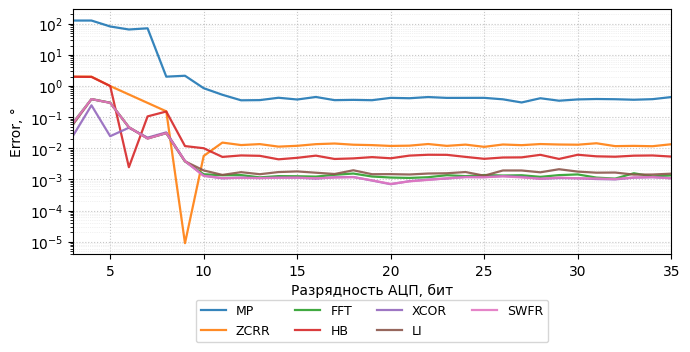

In [35]:
bits_loaded = load_analyze_and_plot(
    variable_name="bits",
    spike_rules={
        "get_phase_XCOR": {
            "x_start": 10,
            "y_threshold": 1e-1
        },

        "get_phase_ZCRR": {
            "x_start": 3,
            "lower_threshold": 1e-8
        }
    }
)

In [ ]:
x=["1","2","3","4","5","6","Прямое включение"]
y=["2.3","2.3"]